In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/Fraudulent Transactions Data.csv')
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.00,0.00,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.00,0.00,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.00,0.00,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.00,0.00,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.00,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
314694,16,CASH_OUT,359950.11,C622142425,11719.0,0.00,C1848110361,2181900.90,2717203.17,0.0,0.0
314695,16,PAYMENT,4032.79,C861304824,3509.0,0.00,M982320760,0.00,0.00,0.0,0.0
314696,16,CASH_IN,114371.60,C829816201,20467.0,134838.60,C671501829,747527.75,633156.15,0.0,0.0
314697,16,PAYMENT,13415.82,C1030884245,82291.0,68875.18,M1025196660,0.00,0.00,0.0,0.0


In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,314699.000000,3.146990e+05,3.146980e+05,3.146980e+05,3.146980e+05,3.146980e+05,314698.000000,314698.0
mean,11.636214,1.757438e+05,8.865920e+05,9.054732e+05,9.786492e+05,1.194413e+06,0.000594,0.0
std,2.725433,2.986535e+05,2.867410e+06,2.904734e+06,2.367532e+06,2.587206e+06,0.024369,0.0
min,1.000000,3.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,10.000000,1.286067e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,12.000000,7.864058e+04,1.835857e+04,0.000000e+00,8.890536e+04,1.949259e+05,0.000000,0.0
75%,14.000000,2.317330e+05,1.812713e+05,2.201000e+05,8.624901e+05,1.236109e+06,0.000000,0.0
max,16.000000,1.000000e+07,3.893942e+07,3.894623e+07,4.133844e+07,4.138365e+07,1.000000,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314699 entries, 0 to 314698
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            314699 non-null  int64  
 1   type            314699 non-null  object 
 2   amount          314699 non-null  float64
 3   nameOrig        314698 non-null  object 
 4   oldbalanceOrg   314698 non-null  float64
 5   newbalanceOrig  314698 non-null  float64
 6   nameDest        314698 non-null  object 
 7   oldbalanceDest  314698 non-null  float64
 8   newbalanceDest  314698 non-null  float64
 9   isFraud         314698 non-null  float64
 10  isFlaggedFraud  314698 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 26.4+ MB


In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,1
oldbalanceOrg,1
newbalanceOrig,1
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [ ]:
for column in df.select_dtypes(include=['number']).columns:
    df[column].fillna(df[column].mean(), inplace=True)
df

<ipython-input-7-942da9edf89e>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.000000,160296.36000,M1979787155,0.000000e+00,0.000000e+00,0.000000,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.000000,19384.72000,M2044282225,0.000000e+00,0.000000e+00,0.000000,0.0
2,1,TRANSFER,181.00,C1305486145,181.000000,0.00000,C553264065,0.000000e+00,0.000000e+00,1.000000,0.0
3,1,CASH_OUT,181.00,C840083671,181.000000,0.00000,C38997010,2.118200e+04,0.000000e+00,1.000000,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.000000,29885.86000,M1230701703,0.000000e+00,0.000000e+00,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...
314694,16,CASH_OUT,359950.11,C622142425,11719.000000,0.00000,C1848110361,2.181901e+06,2.717203e+06,0.000000,0.0
314695,16,PAYMENT,4032.79,C861304824,3509.000000,0.00000,M982320760,0.000000e+00,0.000000e+00,0.000000,0.0
314696,16,CASH_IN,114371.60,C829816201,20467.000000,134838.60000,C671501829,7.475278e+05,6.331562e+05,0.000000,0.0
314697,16,PAYMENT,13415.82,C1030884245,82291.000000,68875.18000,M1025196660,0.000000e+00,0.000000e+00,0.000000,0.0


In [ ]:
for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)
df

<ipython-input-8-1221f6555029>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.000000,160296.36000,M1979787155,0.000000e+00,0.000000e+00,0.000000,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.000000,19384.72000,M2044282225,0.000000e+00,0.000000e+00,0.000000,0.0
2,1,TRANSFER,181.00,C1305486145,181.000000,0.00000,C553264065,0.000000e+00,0.000000e+00,1.000000,0.0
3,1,CASH_OUT,181.00,C840083671,181.000000,0.00000,C38997010,2.118200e+04,0.000000e+00,1.000000,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.000000,29885.86000,M1230701703,0.000000e+00,0.000000e+00,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...
314694,16,CASH_OUT,359950.11,C622142425,11719.000000,0.00000,C1848110361,2.181901e+06,2.717203e+06,0.000000,0.0
314695,16,PAYMENT,4032.79,C861304824,3509.000000,0.00000,M982320760,0.000000e+00,0.000000e+00,0.000000,0.0
314696,16,CASH_IN,114371.60,C829816201,20467.000000,134838.60000,C671501829,7.475278e+05,6.331562e+05,0.000000,0.0
314697,16,PAYMENT,13415.82,C1030884245,82291.000000,68875.18000,M1025196660,0.000000e+00,0.000000e+00,0.000000,0.0


In [ ]:
df = df.drop_duplicates()
df


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.000000,160296.36000,M1979787155,0.000000e+00,0.000000e+00,0.000000,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.000000,19384.72000,M2044282225,0.000000e+00,0.000000e+00,0.000000,0.0
2,1,TRANSFER,181.00,C1305486145,181.000000,0.00000,C553264065,0.000000e+00,0.000000e+00,1.000000,0.0
3,1,CASH_OUT,181.00,C840083671,181.000000,0.00000,C38997010,2.118200e+04,0.000000e+00,1.000000,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.000000,29885.86000,M1230701703,0.000000e+00,0.000000e+00,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...
314694,16,CASH_OUT,359950.11,C622142425,11719.000000,0.00000,C1848110361,2.181901e+06,2.717203e+06,0.000000,0.0
314695,16,PAYMENT,4032.79,C861304824,3509.000000,0.00000,M982320760,0.000000e+00,0.000000e+00,0.000000,0.0
314696,16,CASH_IN,114371.60,C829816201,20467.000000,134838.60000,C671501829,7.475278e+05,6.331562e+05,0.000000,0.0
314697,16,PAYMENT,13415.82,C1030884245,82291.000000,68875.18000,M1025196660,0.000000e+00,0.000000e+00,0.000000,0.0


In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


<ipython-input-11-006b2aada8a4>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='viridis')


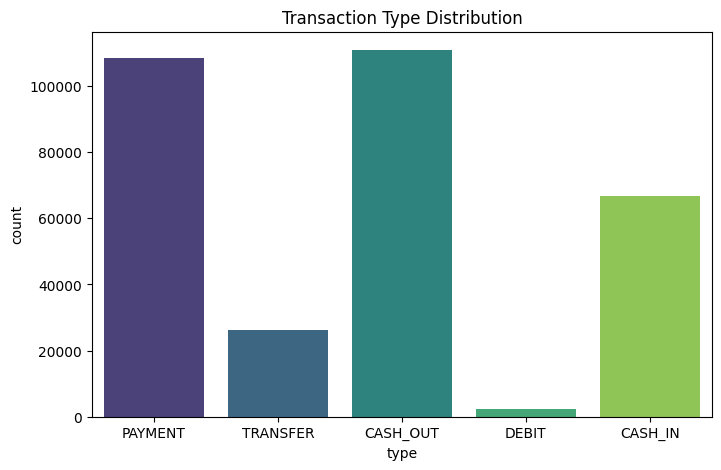

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='type', data=df, palette='viridis')
plt.title("Transaction Type Distribution")
plt.show()

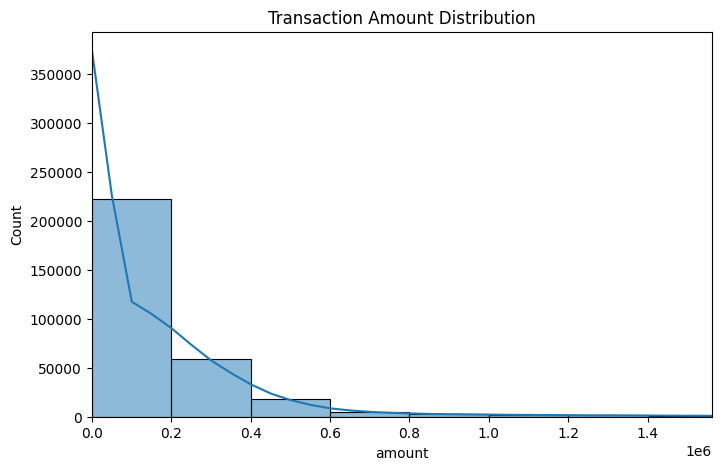

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['amount'], bins=50, kde=True)
plt.xlim(0, df['amount'].quantile(0.99))  # Avoid extreme outliers
plt.title("Transaction Amount Distribution")
plt.show()

<ipython-input-13-4251647d8a77>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='isFraud', data=df, palette='coolwarm')


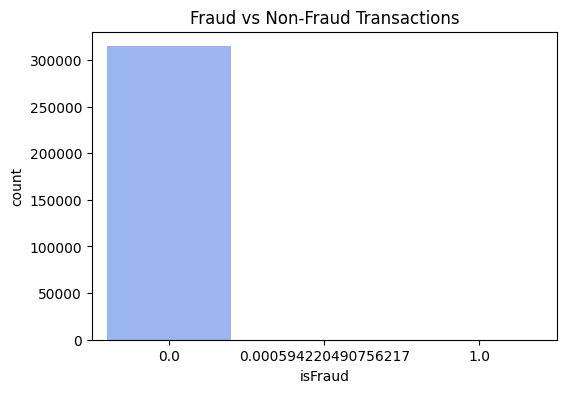

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=df, palette='coolwarm')
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

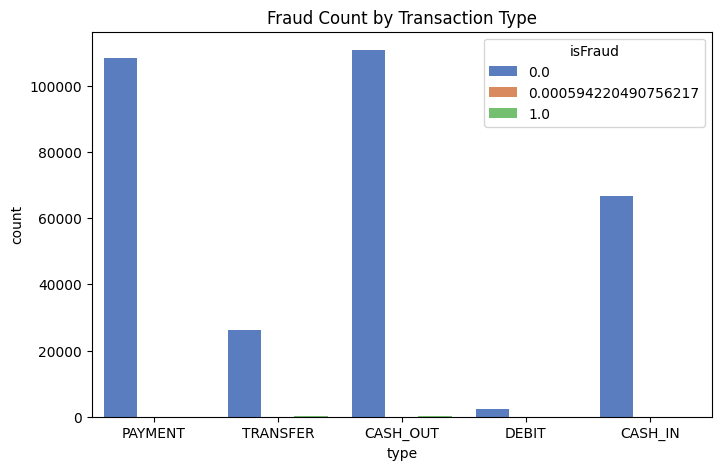

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='type', hue='isFraud', data=df, palette='muted')
plt.title("Fraud Count by Transaction Type")
plt.show()

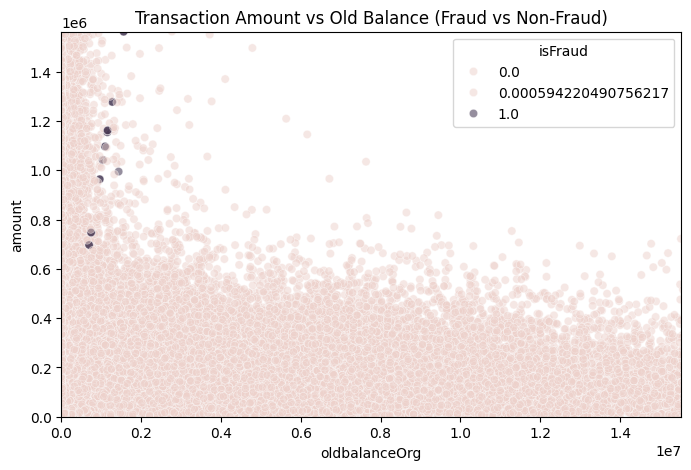

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['oldbalanceOrg'], y=df['amount'], hue=df['isFraud'], alpha=0.5)
plt.xlim(0, df['oldbalanceOrg'].quantile(0.99))
plt.ylim(0, df['amount'].quantile(0.99))
plt.title("Transaction Amount vs Old Balance (Fraud vs Non-Fraud)")
plt.show()

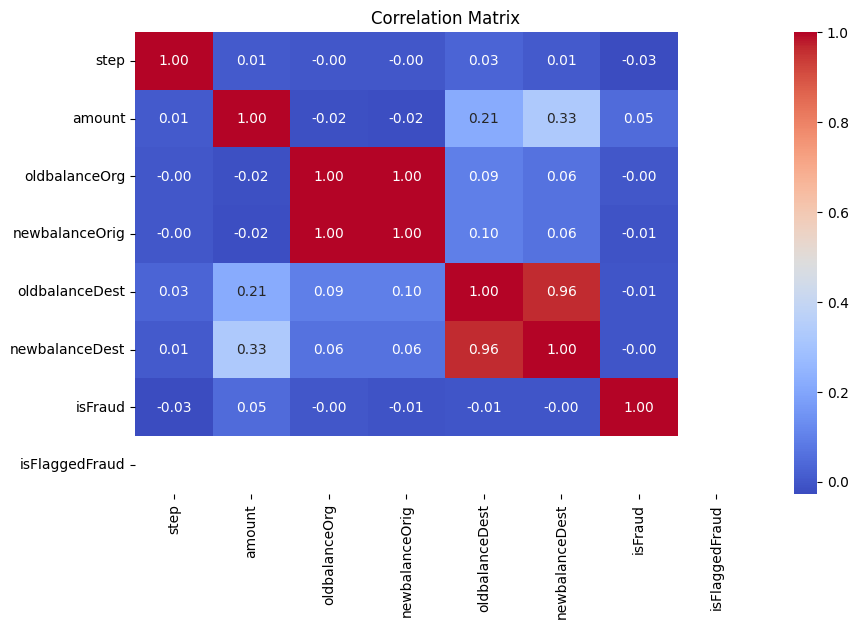

In [ ]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

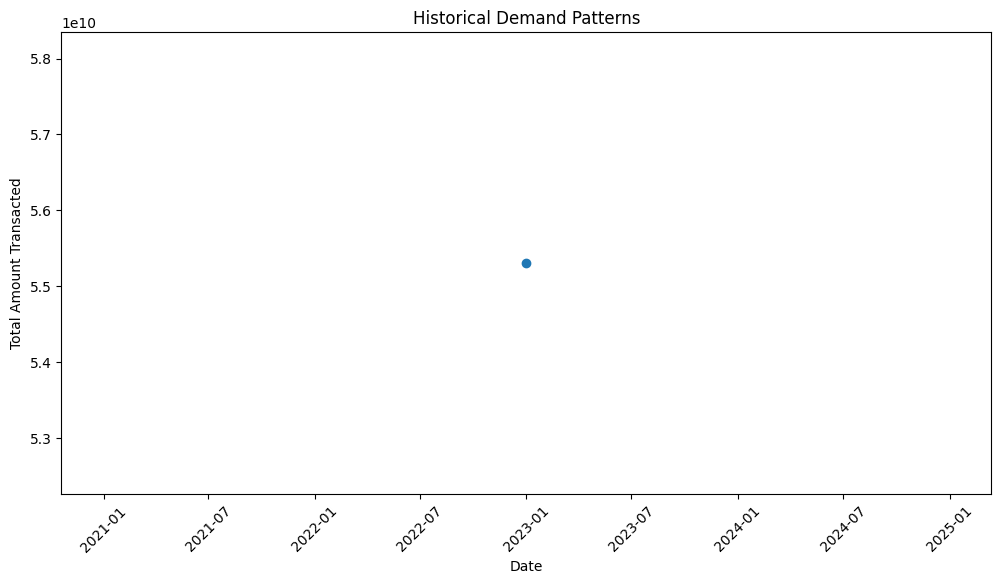

In [ ]:
df['step'] = pd.to_datetime(df['step'], unit='h', origin=pd.Timestamp('2023-01-01'))
demand_trends = df.groupby(df['step'].dt.date)['amount'].sum()
plt.figure(figsize=(12, 6))
plt.plot(demand_trends, marker='o', linestyle='-')
plt.xticks(rotation=45)
plt.title("Historical Demand Patterns")
plt.xlabel("Date")
plt.ylabel("Total Amount Transacted")
plt.show()

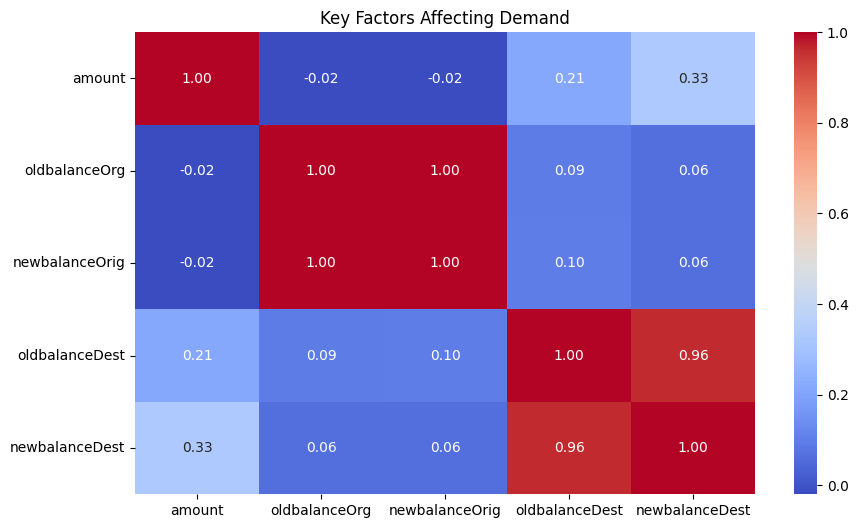

In [ ]:
correlation_demand = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_demand, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Key Factors Affecting Demand")
plt.show()

In [ ]:
df['transaction_gap'] = df.groupby('nameOrig')['step'].diff().fillna(0)
df['balance_change_ratio'] = (df['oldbalanceOrg'] - df['newbalanceOrig']) / (df['oldbalanceOrg'] + 1)
df['recipient_balance_change'] = (df['oldbalanceDest'] - df['newbalanceDest']) / (df['oldbalanceDest'] + 1)
df['large_transaction_flag'] = np.where(df['amount'] > 200000, 1, 0)
df['zero_balance_after_txn'] = np.where(df['newbalanceOrig'] == 0, 1, 0)
df


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,competitor_price,price_strategy,transaction_gap,balance_change_ratio,recipient_balance_change,large_transaction_flag,zero_balance_after_txn
0,2023-01-01 01:00:00,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.000000,0.000000e+00,0.000000,0.0,8815.118796,Lower Price,0,0.057834,0.000000,0,0
1,2023-01-01 01:00:00,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.000000,0.000000e+00,0.000000,0.0,1938.094778,Maintain Price,0,0.087731,0.000000,0,0
2,2023-01-01 01:00:00,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.000000,0.000000e+00,1.000000,0.0,165.998248,Lower Price,0,0.994505,0.000000,0,1
3,2023-01-01 01:00:00,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.000000,0.000000e+00,1.000000,0.0,150.739747,Lower Price,0,0.994505,0.999953,0,1
4,2023-01-01 01:00:00,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.000000,0.000000e+00,0.000000,0.0,12585.031697,Maintain Price,0,0.280788,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206149,2023-01-01 13:00:00,PAYMENT,1562.19,C924173775,1312740.12,1311177.93,M113098452,0.000000,0.000000e+00,0.000000,0.0,1555.733031,Lower Price,0,0.001190,0.000000,0,0
206150,2023-01-01 13:00:00,TRANSFER,26029.23,C955702923,11701.00,0.00,C1593503248,0.000000,2.602923e+04,0.000000,0.0,21843.405336,Lower Price,0,0.999915,-26029.230000,0,1
206151,2023-01-01 13:00:00,PAYMENT,5931.93,C1513578873,456824.00,450892.07,M1133902925,0.000000,0.000000e+00,0.000000,0.0,6816.170290,Maintain Price,0,0.012985,0.000000,0,0
206152,2023-01-01 13:00:00,PAYMENT,18011.97,C674603509,450892.07,432880.11,M649670910,0.000000,0.000000e+00,0.000000,0.0,14439.519288,Lower Price,0,0.039947,0.000000,0,0


In [ ]:
def detect_fraud(row):
    if row['type'] == 'TRANSFER' and row['large_transaction_flag'] == 1:
        return 1  # Fraud detected based on transfer rules
    if row['type'] == 'CASH_OUT' and row['zero_balance_after_txn'] == 1:
        return 1  # Fraud detected based on cash-out
    return 0

df['fraud_flag'] = df.apply(detect_fraud, axis=1)

In [ ]:
df['avg_transaction_amount'] = df.groupby('nameOrig')['amount'].transform('mean')
df['transaction_frequency'] = df.groupby('nameOrig')['step'].transform('count')
df['high_frequency_flag'] = np.where(df['transaction_frequency'] > df['transaction_frequency'].quantile(0.95), 1, 0)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,...,price_strategy,transaction_gap,balance_change_ratio,recipient_balance_change,large_transaction_flag,zero_balance_after_txn,fraud_flag,avg_transaction_amount,transaction_frequency,high_frequency_flag
0,2023-01-01 01:00:00,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.000000,0.000000e+00,0.000000,...,Lower Price,0,0.057834,0.000000,0,0,0,9839.64,1,0
1,2023-01-01 01:00:00,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.000000,0.000000e+00,0.000000,...,Maintain Price,0,0.087731,0.000000,0,0,0,1864.28,1,0
2,2023-01-01 01:00:00,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.000000,0.000000e+00,1.000000,...,Lower Price,0,0.994505,0.000000,0,1,0,181.00,1,0
3,2023-01-01 01:00:00,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.000000,0.000000e+00,1.000000,...,Lower Price,0,0.994505,0.999953,0,1,1,181.00,1,0
4,2023-01-01 01:00:00,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.000000,0.000000e+00,0.000000,...,Maintain Price,0,0.280788,0.000000,0,0,0,11668.14,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206149,2023-01-01 13:00:00,PAYMENT,1562.19,C924173775,1312740.12,1311177.93,M113098452,0.000000,0.000000e+00,0.000000,...,Lower Price,0,0.001190,0.000000,0,0,0,1562.19,1,0
206150,2023-01-01 13:00:00,TRANSFER,26029.23,C955702923,11701.00,0.00,C1593503248,0.000000,2.602923e+04,0.000000,...,Lower Price,0,0.999915,-26029.230000,0,1,0,26029.23,1,0
206151,2023-01-01 13:00:00,PAYMENT,5931.93,C1513578873,456824.00,450892.07,M1133902925,0.000000,0.000000e+00,0.000000,...,Maintain Price,0,0.012985,0.000000,0,0,0,5931.93,1,0
206152,2023-01-01 13:00:00,PAYMENT,18011.97,C674603509,450892.07,432880.11,M649670910,0.000000,0.000000e+00,0.000000,...,Lower Price,0,0.039947,0.000000,0,0,0,18011.97,1,0


In [ ]:
df['suspicious_transfer'] = np.where((df['type'] == 'TRANSFER') &
                                     (df['amount'] > df['oldbalanceOrg'] * 0.8), 1, 0)

In [ ]:
df['final_fraud_flag'] = np.where((df['isFraud'] == 1) |
                                  (df['suspicious_transfer'] == 1), True, False)